In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Carregar dataset
df = pd.read_excel("../assets/dataset_velocidade_v2.xlsx")

# Visualizar
print(df.head())


  movimento  tempo  velocidade  flag
0    avanco  1.230    0.065041     0
1    avanco  1.214    0.065898     0
2    avanco  1.213    0.065952     0
3    avanco  1.275    0.062745     0
4    avanco  1.405    0.056940     1


In [2]:
# Codificar movimento (string -> número)
le = LabelEncoder()
df['movimento_num'] = le.fit_transform(df['movimento'])
# Features e target
X = df[['velocidade', 'movimento_num']]
y = df['flag']  # 1 = normal, 0 = anomalia

In [3]:
# Separar treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# Treinar Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [5]:
# Avaliação rápida
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[727   2]
 [  0 109]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       729
           1       0.98      1.00      0.99       109

    accuracy                           1.00       838
   macro avg       0.99      1.00      0.99       838
weighted avg       1.00      1.00      1.00       838



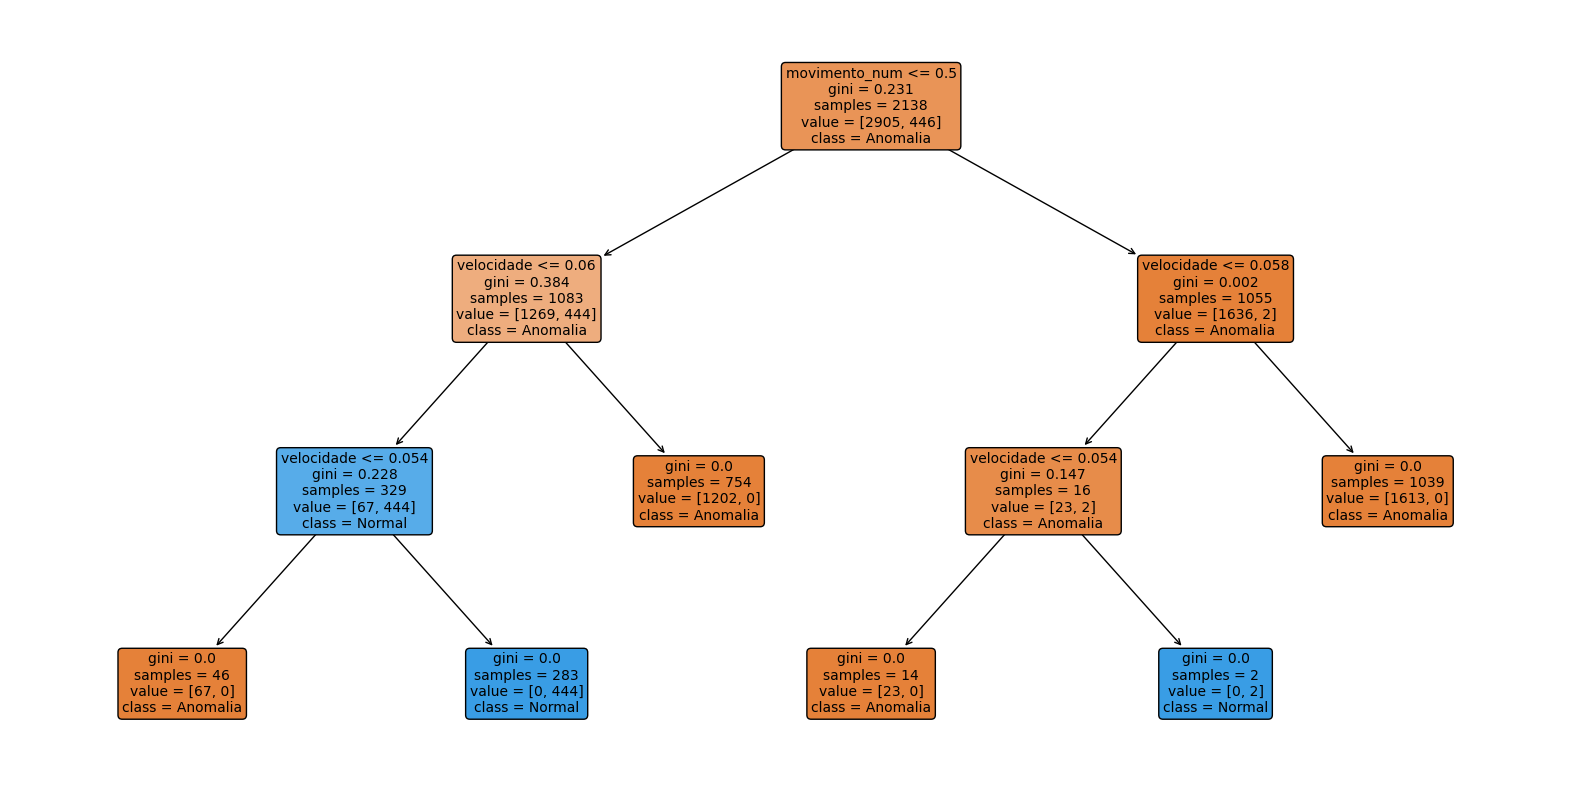

In [6]:
import matplotlib.pyplot as plt
from sklearn import tree

# Selecionar a primeira árvore do Random Forest
estimator = model.estimators_[0]

# Plotar a árvore
plt.figure(figsize=(20,10))
tree.plot_tree(
    estimator, 
    feature_names=['velocidade', 'movimento_num'], 
    class_names=['Anomalia', 'Normal'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Quantidade de amostras de teste
n_test = 20

# Velocidade ideal e margens (usado só para gerar dados sintéticos)
vel_ideal = 0.0571
limite_inferior = vel_ideal * 0.95  # 0.054245
limite_superior = vel_ideal * 1.05  # 0.059955

# Gerar movimentos aleatórios
movimentos = np.random.choice(['avanco', 'recuo'], size=n_test)

# Gerar velocidades:
# 90% normais dentro da faixa, 10% anomalias fora
velocidades = np.concatenate([
    # normais
    np.random.uniform(limite_inferior, limite_superior, int(n_test * 0.9)),

    # anomalias: metade abaixo, metade acima
    np.random.choice(np.concatenate([
        np.random.uniform(0.040, limite_inferior - 0.001, int(n_test * 0.05)),   # abaixo
        np.random.uniform(limite_superior + 0.001, 0.070, int(n_test * 0.05))    # acima
    ]), int(n_test * 0.1), replace=False)
])

# Embaralhar os valores para não ficar agrupado
np.random.shuffle(velocidades)

# Criar dataframe
df_test = pd.DataFrame({
    'movimento': movimentos,
    'velocidade': velocidades
})

# Codificar movimento (LabelEncoder)
le = LabelEncoder()
df_test['movimento_num'] = le.fit_transform(df_test['movimento'])

# ---- Previsão com modelo RandomForest já treinado ----
y_pred = model.predict(df_test[['velocidade', 'movimento_num']])
df_test['pred_flag'] = y_pred
df_test['status_modelo'] = df_test['pred_flag'].map({1: "Normal", 0: "Anômalo"})

# Mostrar resultado
print(df_test)


   movimento  velocidade  movimento_num  pred_flag status_modelo
0      recuo    0.058028              1          1        Normal
1      recuo    0.058735              1          1        Normal
2      recuo    0.055833              1          1        Normal
3      recuo    0.056070              1          1        Normal
4      recuo    0.068237              1          0       Anômalo
5      recuo    0.059580              1          0       Anômalo
6      recuo    0.056577              1          1        Normal
7     avanco    0.058855              0          1        Normal
8     avanco    0.056082              0          1        Normal
9      recuo    0.057819              1          1        Normal
10    avanco    0.055744              0          1        Normal
11     recuo    0.054587              1          0       Anômalo
12    avanco    0.058357              0          1        Normal
13     recuo    0.054369              1          0       Anômalo
14    avanco    0.051729 